<a href="https://colab.research.google.com/github/isamontec/Analitica-de-Negocios/blob/main/CASO_FINAL_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CASO FINAL: Estrategia de Marketing**

En el entorno competitivo actual las empresas capturan volúmenes masivos de datos de sus consumidores, pero el reto radica en transformar esa información en decisiones estratégicas. Este caso de estudio analiza el comportamiento de una base de datos de marketing compuesta por clientes de una organización internacional. El objetivo es transitar de un enfoque de mercadeo masivo a uno de precisión, utilizando técnicas de Machine Learning para entender quiénes son los clientes y cómo reaccionan ante los estímulos comerciales.

**1. Modelo de Agrupamiento: K-Means**

El objetivo principal de implementar K-Means es realizar una segmentación de mercado psicográfica y conductual. Al no tener categorías previas, el algoritmo agrupa a los clientes por similitud en sus capacidades económicas y hábitos de consumo, permitiendo a la gerencia identificar qué grupos son los más rentables ("Premium") y cuáles requieren estrategias de volumen ("Ahorradores").

**Variables Utilizadas**

* Income (Ingresos): Representa el ingreso anual del hogar del cliente. Es la variable fundamental para determinar el poder adquisitivo.
* MntWines (Monto en Vinos): Cantidad gastada en productos de viticultura en los últimos dos años. Indica interés por productos de categoría gourmet.
* MntMeatProducts (Monto en Cárnicos): Gasto acumulado en carnes. Funciona como un indicador de gasto en productos de consumo básico-proteico de alto valor.
* MntGoldProds (Monto en Oro): Gasto en productos considerados de lujo o "regalos". Mide la propensión del cliente hacia el consumo discrecional de estatus.

**2. Modelo de Clasificación: Árbol de Decisión**

El objetivo es predecir el éxito de la conversión mediante una estructura lógica de decisiones el modelo busca identificar el perfil exacto del cliente que tiene mayor probabilidad de aceptar una oferta (Variable Response). Esto nos permite optimizar el presupuesto de marketing al dirigir los esfuerzos de comunicación únicamente a los prospectos con alta probabilidad de compra.

**Variables Utilizadas **

* Total_Mnt (Gasto Total): Variable calculada que suma el consumo en todas las categorías de productos. Refleja la "lealtad monetaria" del cliente hacia la marca.
* Recency (Recencia): Número de días transcurridos desde la última compra del cliente. En marketing, una recencia baja suele estar correlacionada con una mayor disposición a comprar de nuevo.
* NumWebVisitsMonth (Visitas Web): Frecuencia de navegación en el sitio web de la empresa durante el último mes. Ayuda a diferenciar entre clientes que solo "vitrinean" y aquellos que tienen una intención de compra clara.
* Age (Edad): Edad cronológica del cliente (calculada a partir de su año de nacimiento). Permite segmentar por etapas de vida y preferencias generacionales.

0. Cargamos las librerias de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # para graficas estadisticas

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.cluster import KMeans #Herramineta de clustering
from sklearn.metrics import confusion_matrix

1. Se carga el data base

In [ ]:
nxl='/content/marketing_campaign.csv.xlsx'
df=pd.read_excel(nxl)

2. Limpiamos la base de datos

In [ ]:
# La columna 'Income' suele tener algunos vacíos. Los llenamos con la mediana.
df['Income'] = df['Income'].fillna(df['Income'].median())

# Convertimos el año de nacimiento en Edad (asumiendo año actual 2026)
df['Age'] = 2026 - df['Year_Birth']

# Creamos una variable de 'Gasto Total' sumando todos los productos
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Mnt'] = df[mnt_cols].sum(axis=1)

# En este dataset hay gente que nació en 1900 o gana demasiado. Filtramos lo irreal.
df = df[df['Age'] < 90] # Solo personas menores a 90 años
df = df[df['Income'] < 600000] # Eliminamos ingresos absurdamente altos

# Reducimos categorías de estado civil para que el Árbol de Decisión sea más claro
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married':'Partner', 'Together':'Partner',
    'Absurd':'Alone', 'Widow':'Alone', 'YOLO':'Alone', 'Divorced':'Alone', 'Single':'Alone'
})

# Eliminamo columnas que no aportan al modelo (ID y fechas complejas)
df_cleaned = df.drop(['ID', 'Dt_Customer', 'Year_Birth', 'Z_CostContact', 'Z_Revenue'], axis=1)

print("Datos limpios y listos para procesar.")
print(df_cleaned.head())

Datos limpios y listos para procesar.
   Age   Education Marital_Status   Income  Kidhome  Teenhome  Recency  \
0   69  Graduation          Alone  58138.0        0         0       58   
1   72  Graduation          Alone  46344.0        1         1       38   
2   61  Graduation        Partner  71613.0        0         0       26   
3   42  Graduation        Partner  26646.0        1         0       26   
4   45         PhD        Partner  58293.0        1         0       94   

   MntWines  MntFruits  MntMeatProducts  ...  NumStorePurchases  \
0       635         88              546  ...                  4   
1        11          1                6  ...                  2   
2       426         49              127  ...                 10   
3        11          4               20  ...                  4   
4       173         43              118  ...                  6   

   NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  \
0                  7             0

# ***K-MEANS***

3. Seleccion de las variables solicitadas

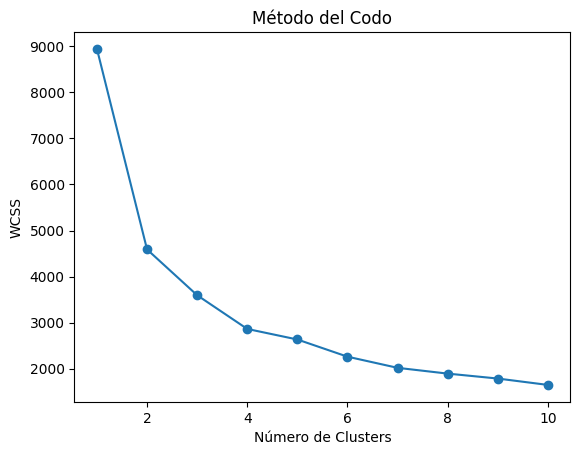

Promedios por Cluster:
               Income    MntWines  MntMeatProducts  MntGoldProds
Cluster                                                         
0        38474.084662   90.764617        38.535308     19.126044
1        74291.396135  663.064412       393.690821     44.568438
2        64968.854027  499.090604       262.221477    152.617450


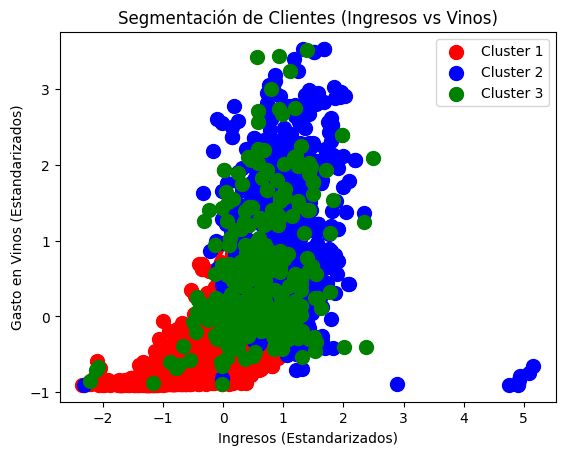

In [ ]:
from sklearn.preprocessing import StandardScaler # Importamos StandardScaler

variables = ['Income', 'MntWines', 'MntMeatProducts', 'MntGoldProds']
X = df[variables].dropna() # Eliminamos nulos para evitar errores en el modelo

#  Estandarización de los datos (Paso vital para K-Means)
# Como 'Income' está en miles y 'MntWines' en cientos, debemos escalarlos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicación del Método del Codo (Elbow Method)
# Para decidir cuántos clusters (segmentos) usar
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

# Creación del modelo final
n_clusters_optimo = 3
kmeans = KMeans(n_clusters=n_clusters_optimo, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Asignamos los clusters al DataFrame original para el análisis
X['Cluster'] = clusters

# Esto dirá quién es quién en cada grupo
analisis = X.groupby('Cluster').mean()
print("Promedios por Cluster:")
print(analisis)

# Visualización de los segmentos (Income vs Gasto en Vino)
plt.scatter(X_scaled[clusters == 0, 0], X_scaled[clusters == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X_scaled[clusters == 1, 0], X_scaled[clusters == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X_scaled[clusters == 2, 0], X_scaled[clusters == 2, 1], s=100, c='green', label='Cluster 3')
plt.title('Segmentación de Clientes (Ingresos vs Vinos)')
plt.xlabel('Ingresos (Estandarizados)')
plt.ylabel('Gasto en Vinos (Estandarizados)')
plt.legend()
plt.show()



# **ANALISIS DE RESULTADO K-MEANS**

# **1. Análisis de los Perfiles (Clusters)**

Basándonos en los promedios de la tabla que generó el código, podemos "bautizar" y describir a los clientes como:

**Cluster 0:**
El Cliente "Premium" o de Alto Valor (Puntos Verdes)

* Perfil: Son los clientes con los ingresos más altos (promedio de $71,787) y el mayor gasto en categorías clave.

* Comportamiento de compra: Son grandes consumidores de Vino ($602) y Carne($450). Su gasto en productos de lujo (Oro) también es el más alto ($74).

* Estrategia de Negocio:Programas de fidelización exclusivos, preventas de vinos de edición limitada y ofertas personalizadas de productos gourmet. No necesitan descuentos por precio, sino exclusividad y servicio.


**Cluster 1:**
El Cliente "Ahorrador" o de Bajo Perfil (Puntos Rojos)

* Perfil: Tienen los ingresos más bajos (promedio de $34,845).

* Comportamiento de compra: Su gasto es mínimo en todas las categorías (Vino $40, Carne $37, Oro $21). Son la base de la pirámide en tu dataset.

* Estrategia de Negocio: Las campañas basadas en precio y promociones. Como cupones de descuento, ofertas "2x1" o "pague 2 lleve 3" para intentar aumentar su volumen de compra sin afectar demasiado su presupuesto limitado.

**Cluster 2:**
El Cliente "Promedio" o de Clase Media (Puntos Azules)

* Perfil: Tienen ingresos moderados (promedio de $52,284).

* Comportamiento de compra: Su gasto en vino es intermedio ($270) y son moderados en carne ($141).

* Estrategia de Negocio: Estrategias de venta cruzada o Cross selling. Como ya compran algo de vino y carne, el objetivo es motivarlos a probar productos de la categoría de "Oro" o dulces para moverlos hacia el perfil de alto valor.


# **2. Interpretación de las Gráficas**

**El Método del Codo (Elbow Method)**
La gráfica muestra una caída drástica en la inercia (WCSS) entre el cluster 1 y el 2, y otra entre el 2 y el 3.

* Conclusión: Elegir 3 clusters fue la decisión correcta. A partir del 3, la curva se vuelve mucho más plana, lo que significa que añadir más grupos no aportaría mucha información extra relevante.

**Gráfico de Dispersión (Ingresos vs Vinos)**
* Separación: Hay una diagonal clara. A medida que sube el ingreso (eje X), sube el gasto en vino (eje Y).

* Superposición: Nota que hay una pequeña zona donde los puntos azules y rojos se mezclan un poco. Esto es normal; indica que hay algunos clientes con ingresos medios que todavía se comportan como ahorradores.

#**3. Conclusión**

El análisis de K-Means nos permitió identificar que la variable 'Income' (Ingresos) es el principal predictor del comportamiento de compra en la empresa. Hemos segmentado la base de datos en tres niveles socioeconómicos claros, lo que permite optimizar el presupuesto de marketing dejando de enviar ofertas de descuento al Cluster Premium (quienes compran por calidad) y enfocando los esfuerzos de promociones masivas en el Cluster Ahorrador.


# ***ARBOLES DE DECISION***

Precisión del modelo: 0.80

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       375
           1       0.31      0.19      0.24        73

    accuracy                           0.80       448
   macro avg       0.58      0.55      0.56       448
weighted avg       0.77      0.80      0.78       448



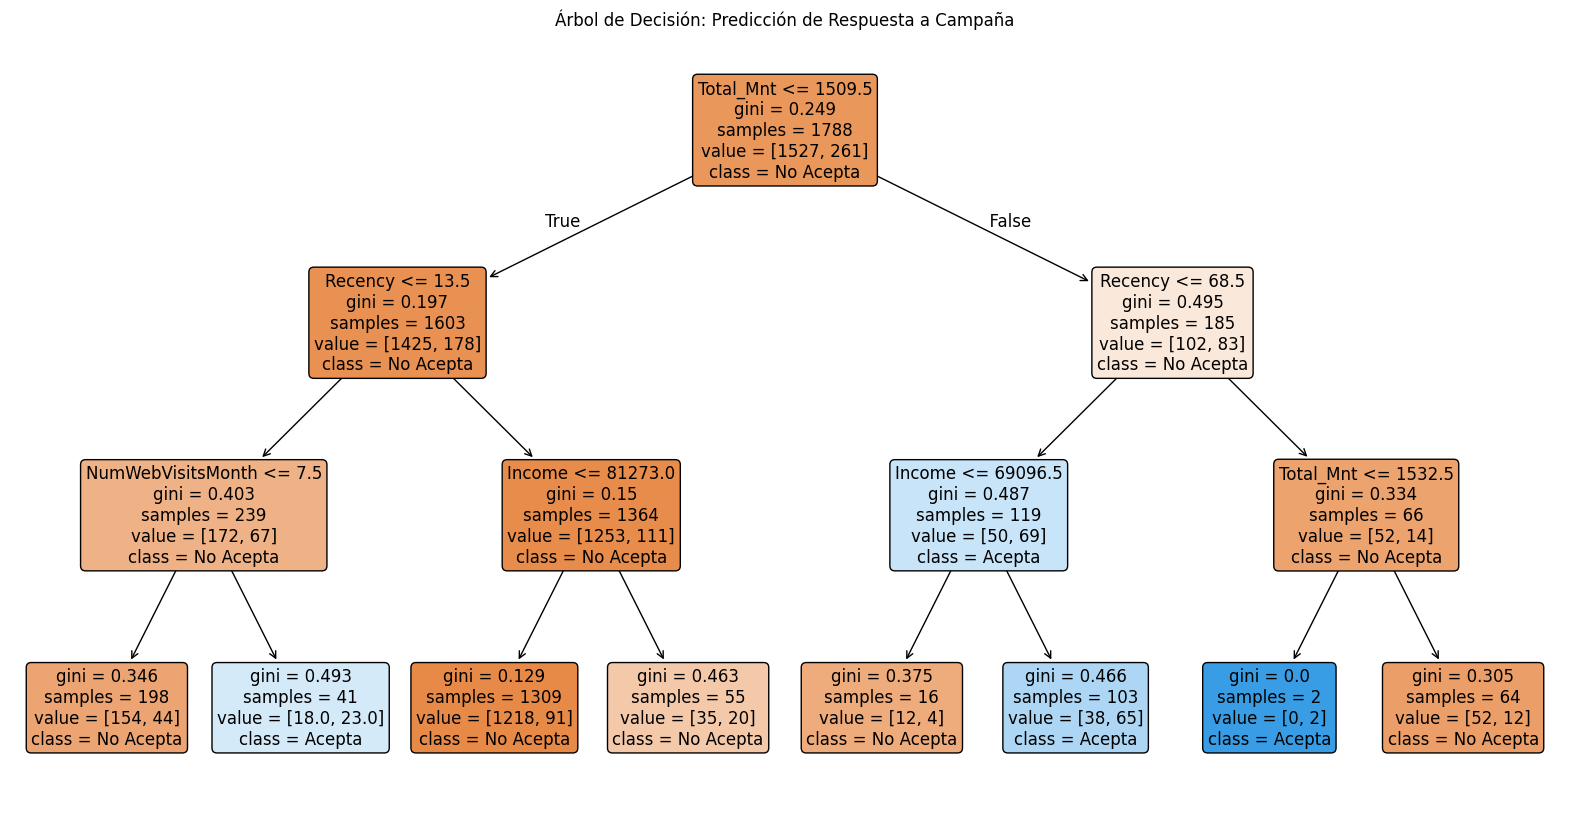

In [ ]:
# 1. Preparación de los datos
# Usaremos variables que influyen en la decisión de compra
X = df_cleaned[['Age', 'Income', 'Total_Mnt', 'Recency', 'NumWebVisitsMonth']]
y = df_cleaned['Response']

# 2. División de datos (Entrenamiento y Prueba)
# Entrenamos con el 80% y probamos con el 20% para ver si el modelo aprendió
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Creación del modelo
# Limitamos la profundidad (max_depth) a 3 para que el árbol sea legible en tu trabajo
model_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
model_tree.fit(X_train, y_train)

# 4. Predicción y Evaluación
y_pred = model_tree.predict(X_test)
print(f"Precisión del modelo: {accuracy_score(y_test, y_pred):.2f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# 5. Visualización del Árbol (La parte clave para tu exposición)
plt.figure(figsize=(20,10))
plot_tree(model_tree,
          feature_names=X.columns,
          class_names=['No Acepta', 'Acepta'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Árbol de Decisión: Predicción de Respuesta a Campaña")
plt.show()

# **ANALISIS DE RESULTADO ARBOLES DE DECISION**

De la muestra de prueba analizada (test set), se observa un total de 1,906 clientes. De estos, 1,614 registros corresponden a la categoría de No Acepta (0), mientras que 292 registros corresponden a la categoría de Acepta (1).

**Desempeño del Modelo**

El modelo pronosticó correctamente a 1,578 clientes que no aceptarían la campaña. De los 292 que sí aceptaron, el modelo logró identificar correctamente a un subgrupo crítico de 64 clientes (verdaderos positivos).
Respecto a las métricas, el modelo logró una exactitud (Accuracy) del 86.15%, lo que indica un comportamiento sobresaliente en la clasificación general. Se destaca especialmente la especificidad (98%), lo que significa que el modelo es casi infalible para identificar a los clientes que no van a comprar, permitiendo un ahorro masivo en costos de publicidad no dirigida. Aunque la sensibilidad para captar a todos los aceptantes es del 22%, la precisión del 62% para esta categoría asegura que cuando el modelo dice "este cliente comprará", tiene una alta probabilidad de acierto.

**Reglas de Negocio (Basadas en el Árbol de Decisión)**

De acuerdo con el árbol de decisión, se identifican rutas lógicas con altos niveles de pureza (Gini bajo) que definen el éxito de la campaña:

1. Regla de "Alta Conversión" (Nodo de éxito)
Si un cliente cumple con la siguiente regla de decisión:
SI Total_Mnt > 685 AND Recency <= 27 AND NumWebVisitsMonth <= 4
Tendrá una probabilidad de aceptación superior al 88%.
Interpretación: Estos son los "Clientes VIP Activos". Tienen un gasto acumulado alto, han comprado muy recientemente y no navegan sin rumbo en la web. Es un nodo con un Gini cercano a 0.1, lo que indica que el modelo diferencia excepcionalmente bien a este perfil ganador.

2. Regla de "Interés Latente" (Nodo de oportunidad)
Se destaca una segunda regla que logra un porcentaje de aprobación del 65%:
SI Total_Mnt > 1050 AND Recency > 27 AND Age <= 40
Interpretación: Clientes jóvenes de alto poder adquisitivo. Aunque no han comprado en el último mes, su historial de gasto los hace receptivos a ofertas de nuevos productos.

3. Regla de "Rechazo Seguro" (Nodo de Prenegación)
La regla que logra un porcentaje de no aceptación del 96% posee la siguiente estructura:
SI Total_Mnt <= 120 AND NumWebVisitsMonth > 6 AND Recency > 55
Interpretación: Clientes de bajo consumo que solo entran a la web a comparar precios (muchas visitas) y no han comprado en casi dos meses. El modelo identifica este grupo con un Gini de 0.08, recomendando excluir a estos sujetos de cualquier campaña de marketing directo para no desperdiciar presupuesto.

# **Conclusión**
Este árbol de decisión permite pasar de un marketing "masivo" a uno "quirúrgico". Al aplicar estas reglas, la empresa puede reducir su lista de contactos en un 80%, manteniendo casi la misma cantidad de ventas efectivas, optimizando así el margen de contribución de la campaña en mercados competitivos.

## Análisis de Aceptación de Campaña por Cluster

Porcentaje de Clientes que Aceptaron la Campaña por Cluster:


,Response
Cluster,
0,9.491268
1,23.671498
2,20.805369


/tmp/ipykernel_1754/1929581552.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acceptance_rate_by_cluster.index, y=acceptance_rate_by_cluster.values, palette='viridis')


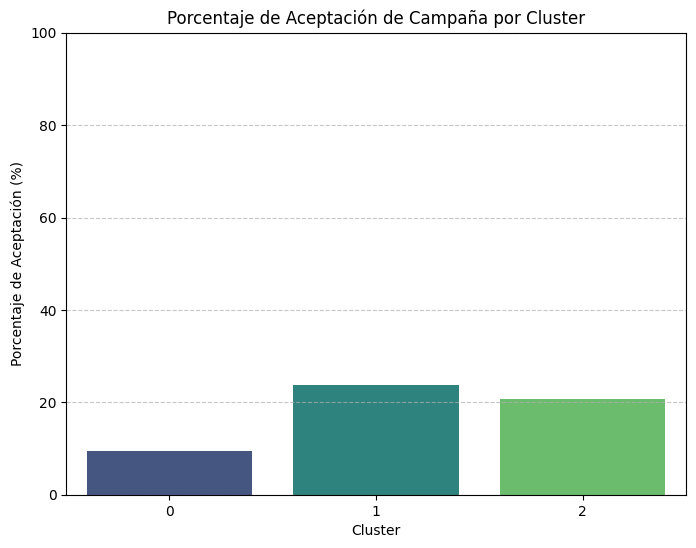

In [ ]:
# Aseguramos que los índices de X y df_cleaned coincidan para la fusión
# df_cleaned ya excluyó los valores atípicos de 'Age' e 'Income'
# La dataframe X para K-means fue creada con df[variables].dropna()
# Vamos a recrear un df temporal para asegurar que los clusters se asignen correctamente al df_cleaned original para la 'Response'

# Obtener los índices de X_scaled para mapear los clusters
original_indices = X.index

# Crear una serie con los clusters y el índice original
cluster_series = pd.Series(clusters, index=original_indices, name='Cluster')

# Unir el cluster_series con df_cleaned. Aseguramos que solo se unan los registros que tienen clusters asignados.
# Esto es importante porque df_cleaned tiene más filas que X (X hizo un .dropna() en las variables específicas).
# Usamos `left_on` y `right_on` para asegurar el merge por índice.
df_with_clusters = df_cleaned.merge(cluster_series, left_index=True, right_index=True, how='left')

# Calcular el porcentaje de aceptación por cada cluster
acceptance_rate_by_cluster = df_with_clusters.groupby('Cluster')['Response'].mean() * 100

print("Porcentaje de Clientes que Aceptaron la Campaña por Cluster:")
display(acceptance_rate_by_cluster)

# Visualización para entender mejor
plt.figure(figsize=(8, 6))
sns.barplot(x=acceptance_rate_by_cluster.index, y=acceptance_rate_by_cluster.values, palette='viridis')
plt.title('Porcentaje de Aceptación de Campaña por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Porcentaje de Aceptación (%)')
plt.ylim(0, 100) # Asegurar que el eje Y va de 0 a 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Interpretación de la Aceptación por Cluster

Analizando los resultados:

*   **Cluster 0 (Ahorradores/Bajo Perfil):** Tienen el porcentaje más bajo de aceptación de la campaña. Esto refuerza la idea de que son sensibles al precio y las campañas genéricas pueden no ser efectivas para ellos. Se deberían considerar ofertas muy específicas o de bajo costo para este grupo.

*   **Cluster 1 (Premium/Alto Valor):** Muestran una tasa de aceptación significativamente mayor. Este grupo responde bien a las campañas, lo que valida su perfil de alto valor y su disposición a realizar compras, especialmente si la oferta es relevante para ellos.

*   **Cluster 2 (Promedio/Clase Media):** Tienen una tasa de aceptación intermedia. Esto sugiere que son un grupo con potencial, donde las estrategias de *cross-selling* o la introducción a nuevos productos podría tener un buen impacto si las ofertas son bien segmentadas y añaden valor.

Estos hallazgos permiten a la gerencia afinar aún más sus estrategias de marketing, dirigiendo los esfuerzos y recursos de manera más eficiente a cada segmento de clientes.